# Model Training

This notebook contains the steps for training various ML models on the PV dataset.

In [37]:
# Import libraries
import os
import time
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
import xgboost as xgb 

# Define the file path relative to the current notebook directory
base_path = os.path.join("..", "data", "processed")
results_path = os.path.join("..", "results")
os.makedirs(results_path, exist_ok=True)

# Load preprocessed data
X_train = pd.read_csv(os.path.join(base_path, "X_train_scaled.csv"))
X_test = pd.read_csv(os.path.join(base_path, "X_test_scaled.csv"))
y_efficiency_train = pd.read_csv(os.path.join(base_path, "y_efficiency_train.csv"))
y_efficiency_test = pd.read_csv(os.path.join(base_path, "y_efficiency_test.csv"))
y_efficiency_level_train = pd.read_csv(os.path.join(base_path, "y_efficiency_level_train.csv"))
y_efficiency_level_test = pd.read_csv(os.path.join(base_path, "y_efficiency_level_test.csv"))
y_efficiency_level_train_int = pd.read_csv(os.path.join(base_path, "y_efficiency_level_train_int.csv"))
y_efficiency_level_test_int = pd.read_csv(os.path.join(base_path, "y_efficiency_level_test_int.csv"))

y_efficiency_train = np.ravel(y_efficiency_train)
y_efficiency_test = np.ravel(y_efficiency_test)
y_efficiency_level_train = np.ravel(y_efficiency_level_train)
y_efficiency_level_test = np.ravel(y_efficiency_level_test)
y_efficiency_level_train_int = np.ravel(y_efficiency_level_train_int)
y_efficiency_level_test_int = np.ravel(y_efficiency_level_test_int)

# 2. Linear Regression
linear_regressor = LinearRegression()
start_time = time.time()
linear_regressor.fit(X_train, y_efficiency_train)
train_time_lr = time.time() - start_time
y_pred_linear_regressor = linear_regressor.predict(X_test)
pd.DataFrame(y_pred_linear_regressor).to_csv(os.path.join(results_path, "linear_regressor_pred.csv"), index=False)


# 4. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
start_time = time.time()
rf.fit(X_train, y_efficiency_level_train)
train_time_rf = time.time() - start_time
y_pred_rf = rf.predict(X_test)
pd.DataFrame(y_pred_rf).to_csv(os.path.join(results_path, "random_forest_pred.csv"), index=False)

# 5. Logistic Regression
logistic_regressor = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
start_time = time.time()
logistic_regressor.fit(X_train, y_efficiency_level_train)
train_time_log = time.time() - start_time
y_pred_logistic = logistic_regressor.predict(X_test)
logreg_probabilities = logistic_regressor.predict_proba(X_test)
pd.DataFrame(logreg_probabilities).to_csv(os.path.join(results_path,"logistic_regression_probabilities.csv"), index=False)
pd.DataFrame(y_pred_logistic).to_csv(os.path.join(results_path, "logistic_regression_pred.csv"), index=False)

# 6. XGBoost Model
## XGBoost Regressor
xgb_regressor = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
start_time = time.time()
xgb_regressor.fit(X_train, y_efficiency_train)
train_time_xg = time.time() - start_time
y_pred_xgb_regressor = xgb_regressor.predict(X_test)
pd.DataFrame(y_pred_xgb_regressor).to_csv(os.path.join(results_path, "xgb_regressor_pred.csv"), index=False)

## XGBoost Classifier
xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False  # Avoids unnecessary warnings
)
start_time = time.time()
xgb_classifier.fit(X_train, y_efficiency_level_train_int)
train_time_xgc = time.time() - start_time
y_pred_xgb_classifier = xgb_classifier.predict(X_test)
xgb_probabilities = xgb_classifier.predict_proba(X_test)
pd.DataFrame(xgb_probabilities).to_csv(os.path.join(results_path,"xgb_classifier_probabilities.csv"), index=False)
pd.DataFrame(y_pred_xgb_classifier).to_csv(os.path.join(results_path, "xgb_classifier_pred.csv"), index=False)


# Create a combined results dictionary with NaN for missing values
combined_results = {
    "Model": [
        "Linear Regression", "XGBoost Regressor", "Random Forest", "Logistic Regression", "XGBoost Classifier"
    ],
    "Mean Squared Error": [
        mean_squared_error(y_efficiency_test, y_pred_linear_regressor),
        mean_squared_error(y_efficiency_test, y_pred_xgb_regressor),
        np.nan, np.nan, np.nan
    ],
    "R-squared": [
        r2_score(y_efficiency_test, y_pred_linear_regressor),
        r2_score(y_efficiency_test, y_pred_xgb_regressor),
        np.nan, np.nan, np.nan
    ],
    "Accuracy": [
        np.nan, np.nan,
        accuracy_score(y_efficiency_level_test, y_pred_rf),
        accuracy_score(y_efficiency_level_test, y_pred_logistic),
        accuracy_score(y_efficiency_level_test_int, y_pred_xgb_classifier)
    ],
    "Training time": [
        train_time_lr,
        train_time_xg,
        train_time_rf,
        train_time_log,
        train_time_xgc
    ]
}

# Convert into DataFrame
combined_df = pd.DataFrame(combined_results)

# Save combined results to CSV
combined_df.to_csv(os.path.join(results_path, "combined_results.csv"), index=False)

# Optionally print to check the DataFrame
print(combined_df)


c:\Users\Utilizador\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:18:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


                 Model  Mean Squared Error  R-squared  Accuracy  Training time
0    Linear Regression        1.415501e-06   0.998680       NaN       0.146468
1    XGBoost Regressor        4.683946e-07   0.999563       NaN       2.110013
2        Random Forest                 NaN        NaN   0.98125      18.874980
3  Logistic Regression                 NaN        NaN   0.98945       3.155069
4   XGBoost Classifier                 NaN        NaN   0.99110       5.605017


Based on the results, we can confidently discard the Random Forest model, as it takes too long to train and does not provide the best accuracy. Therefore, for the classification task, we need to choose between Logistic Regression and the XGBoost Classifier. For the regression task, further analysis is required to determine the best regressor.

The XGBoost Classifier achieved the best performance with an accuracy of 99.110%, but it had a longer training time compared to Logistic Regression. To optimize training time without sacrificing accuracy, we leveraged the feature importance analysis from XGBoost to identify the most significant features. By reducing the dataset to include only these key features, we aimed to streamline training while maintaining the model's high accuracy. We applied the same approach to the XGBoost Regressor as well.

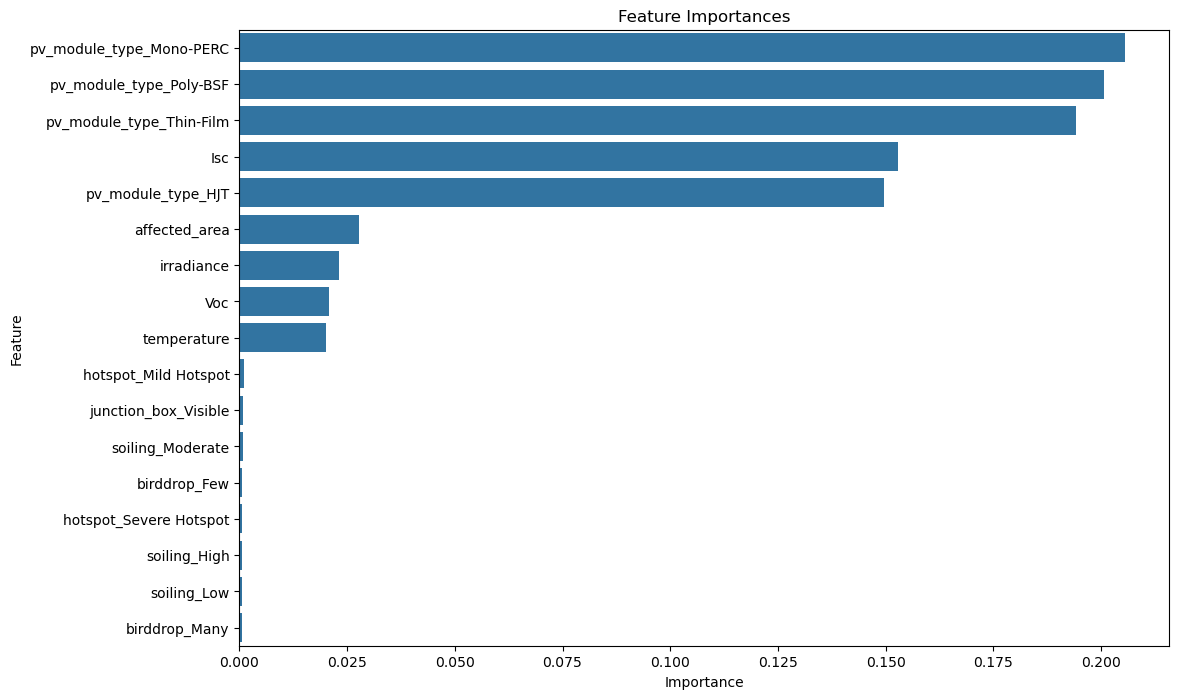

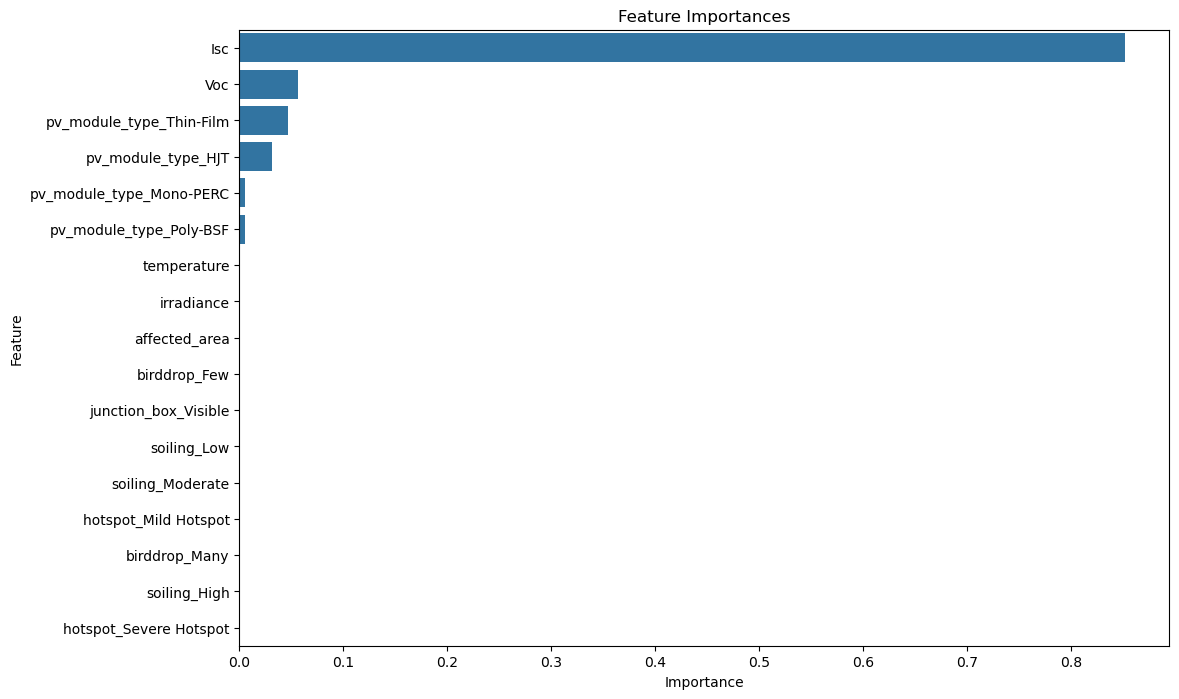

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate feature importances
feature_importances_c = xgb_classifier.feature_importances_ # ver documentação de feature_importance_ para perceber o output

# Create a dataframe to visualize the feature importances
feature_importance_df_c = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances_c
})

# Sort the features by importance
feature_importance_df_c = feature_importance_df_c.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_c)
plt.title('Feature Importances')
plt.show()

# Calculate feature importances
feature_importances_r = xgb_regressor.feature_importances_ # ver documentação de feature_importance_ para perceber o output

# Create a dataframe to visualize the feature importances
feature_importance_df_r = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances_r
})

# Sort the features by importance
feature_importance_df_r = feature_importance_df_r.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_r)
plt.title('Feature Importances')
plt.show()

In [34]:
# Define a threshold for feature importance
threshold = 0.01  # Retain features with importance greater than this value

# Filter out features with importance below the threshold
selected_features = feature_importance_df_c[feature_importance_df_c['Importance'] > threshold]['Feature']

# Subset the training and testing datasets with the selected features
X_train_reduced = X_train[selected_features]
X_test_reduced = X_test[selected_features]

## XGBoost Classifier
xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False  # Avoids unnecessary warnings
)
start_time = time.time()
xgb_classifier.fit(X_train_reduced, y_efficiency_level_train_int)
train_time_xgc = time.time() - start_time
y_pred_xgb_classifier = xgb_classifier.predict(X_test_reduced)
xgb_probabilities = xgb_classifier.predict_proba(X_test_reduced)
pd.DataFrame(xgb_probabilities).to_csv(os.path.join(results_path,"xgb_classifier_probabilities.csv"), index=False)
pd.DataFrame(y_pred_xgb_classifier).to_csv(os.path.join(results_path, "xgb_classifier_pred.csv"), index=False)

# Filter out features with importance below the threshold
selected_features = feature_importance_df_r[feature_importance_df_r['Importance'] > threshold]['Feature']

# Subset the training and testing datasets with the selected features
X_train_reduced = X_train[selected_features]
X_test_reduced = X_test[selected_features]

## XGBoost regressor
xgb_regressor = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
start_time = time.time()
xgb_regressor.fit(X_train_reduced, y_efficiency_train)
train_time_xg = time.time() - start_time
y_pred_xgb_regressor = xgb_regressor.predict(X_test_reduced)

# Create a combined results dictionary with NaN for missing values
combined_results = {
    "Model": [
        "XGBoost Regressor", "XGBoost Classifier"
    ],
    "Mean Squared Error": [
        mean_squared_error(y_efficiency_test, y_pred_xgb_regressor),
        np.nan
    ],
    "R-squared": [
        r2_score(y_efficiency_test, y_pred_xgb_regressor),
        np.nan
    ],
    "Accuracy": [
        np.nan,
        accuracy_score(y_efficiency_level_test_int, y_pred_xgb_classifier)
    ],
    "Training time": [
        train_time_xg,
        train_time_xgc
    ]
}

# Convert into DataFrame
combined_df = pd.DataFrame(combined_results)

print(combined_df)




c:\Users\Utilizador\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:16:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


                Model  Mean Squared Error  R-squared  Accuracy  Training time
0   XGBoost Regressor            0.000001   0.998802       NaN       0.597138
1  XGBoost Classifier                 NaN        NaN   0.99135       4.676785


The approach proved somewhat effective, with the XGBoost Classifier showing a slight increase in accuracy, from 99.110% to 99.135%, and a reduction in training time from 5.60 seconds to 4.68 seconds. Conversely, the XGBoost Regressor, which initially had the best R-squared score of 0.999563 and a training time of 2.11 seconds, saw a decrease in its R-squared value to 0.998802, despite a reduction in training time to 0.597 seconds.

Based on these results, we can conclude that, despite its training time, the XGBoost Classifier is the most effective model for the classification task. Since the training times are not significantly large, there is potential for flexibility between the models. Further analysis will be conducted in the model evaluation notebook to determine the optimal choice for the classification problem.

As for the regression problem, we can chosse either regression model (Linear regression or the XGBoost regressor), but, since the linear regression model trains much faster in comparison to the XGBoost model and is simpler, we recommend it's use for this dataset.